In [3]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns




from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor



from sklearn.metrics import (
    accuracy_score,
    classification_report,
    mean_absolute_error,
    mean_squared_error
)



In [4]:

# =============================================
# 2. LOAD REALISTIC DATASET
# =============================================
df = pd.read_excel("IT_resume_dataset_realistic.xlsx")

print("Dataset Loaded:", df.shape)
df.head()



Dataset Loaded: (10000, 6)


,Name,Experience_Years,Skills,Education,Applied_Job_Role,Salary_USD
0,Candidate_1,6.895116,"JIRA, Scrum, Agile, Retrospective, Sprint Plan...",BCA,Software Engineer,90991.913908
1,Candidate_2,17.019543,"Git, AWS, Node.js, React, Express, MongoDB",BSc Computer Science,Full Stack Developer,196796.492783
2,Candidate_3,18.862661,"SQL, Pandas, TensorFlow, Python, Scikit-learn",BCA,Data Scientist,198247.590322
3,Candidate_4,2.878788,"AWS, Docker, CI/CD, Kubernetes",BCA,AI Engineer,76193.089740
4,Candidate_5,0.286129,"Active Directory, Backup, Shell Scripting, VMware",Diploma in IT,System Administrator,59526.816535


 EXPLORATORY DATA ANALYSIS


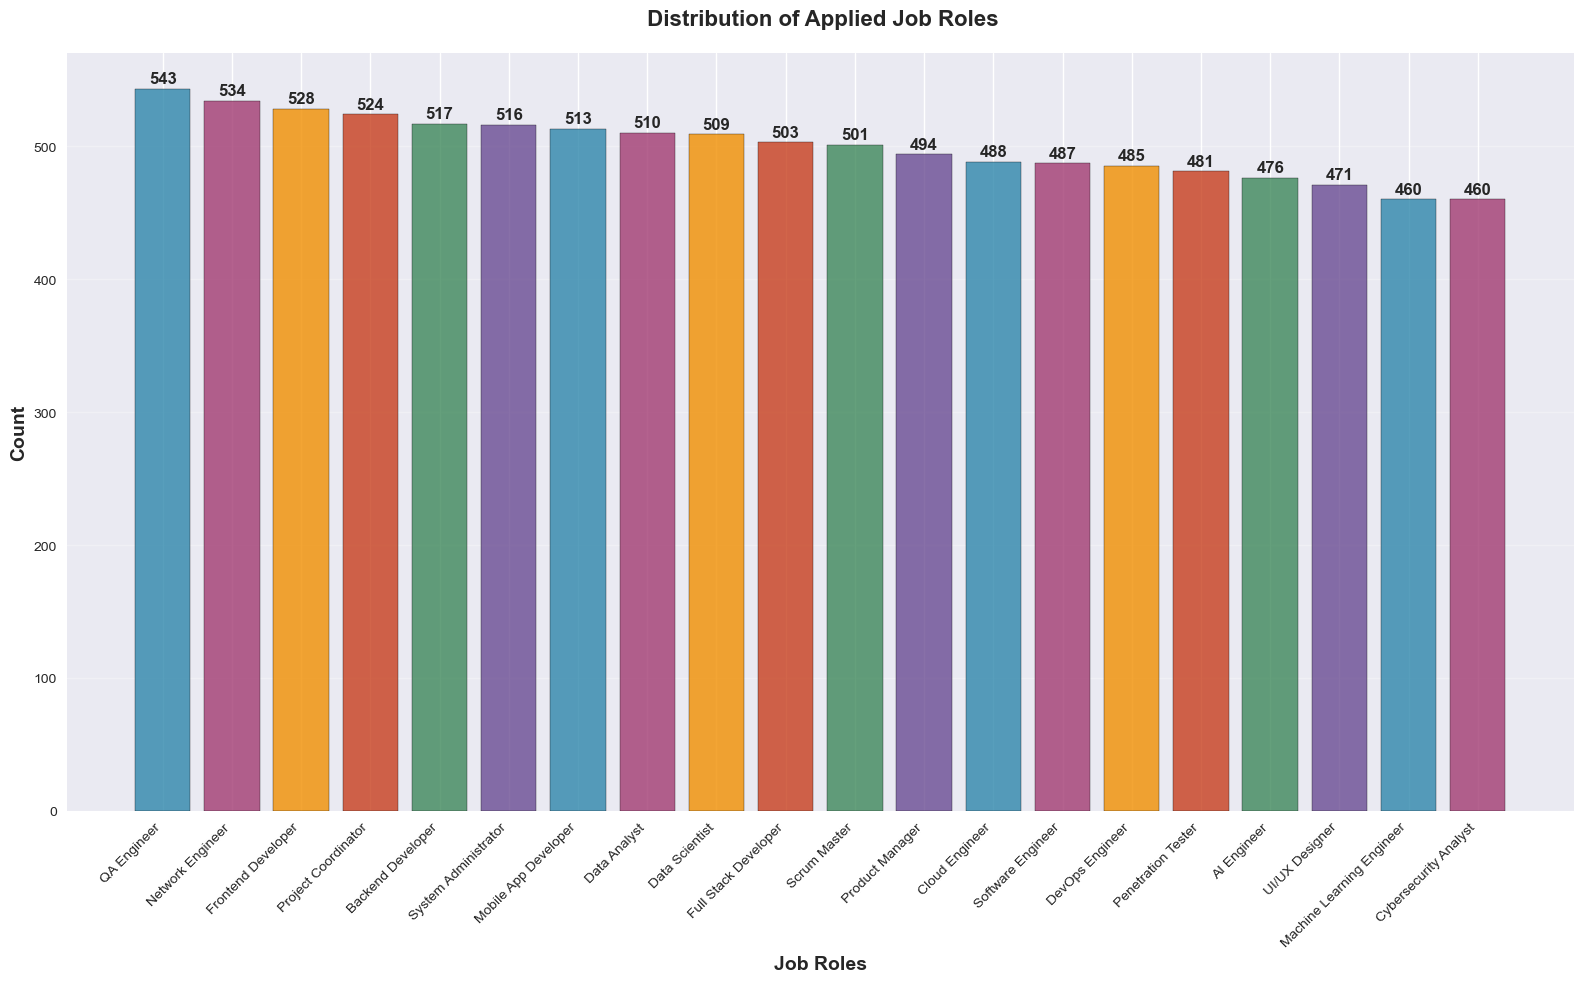

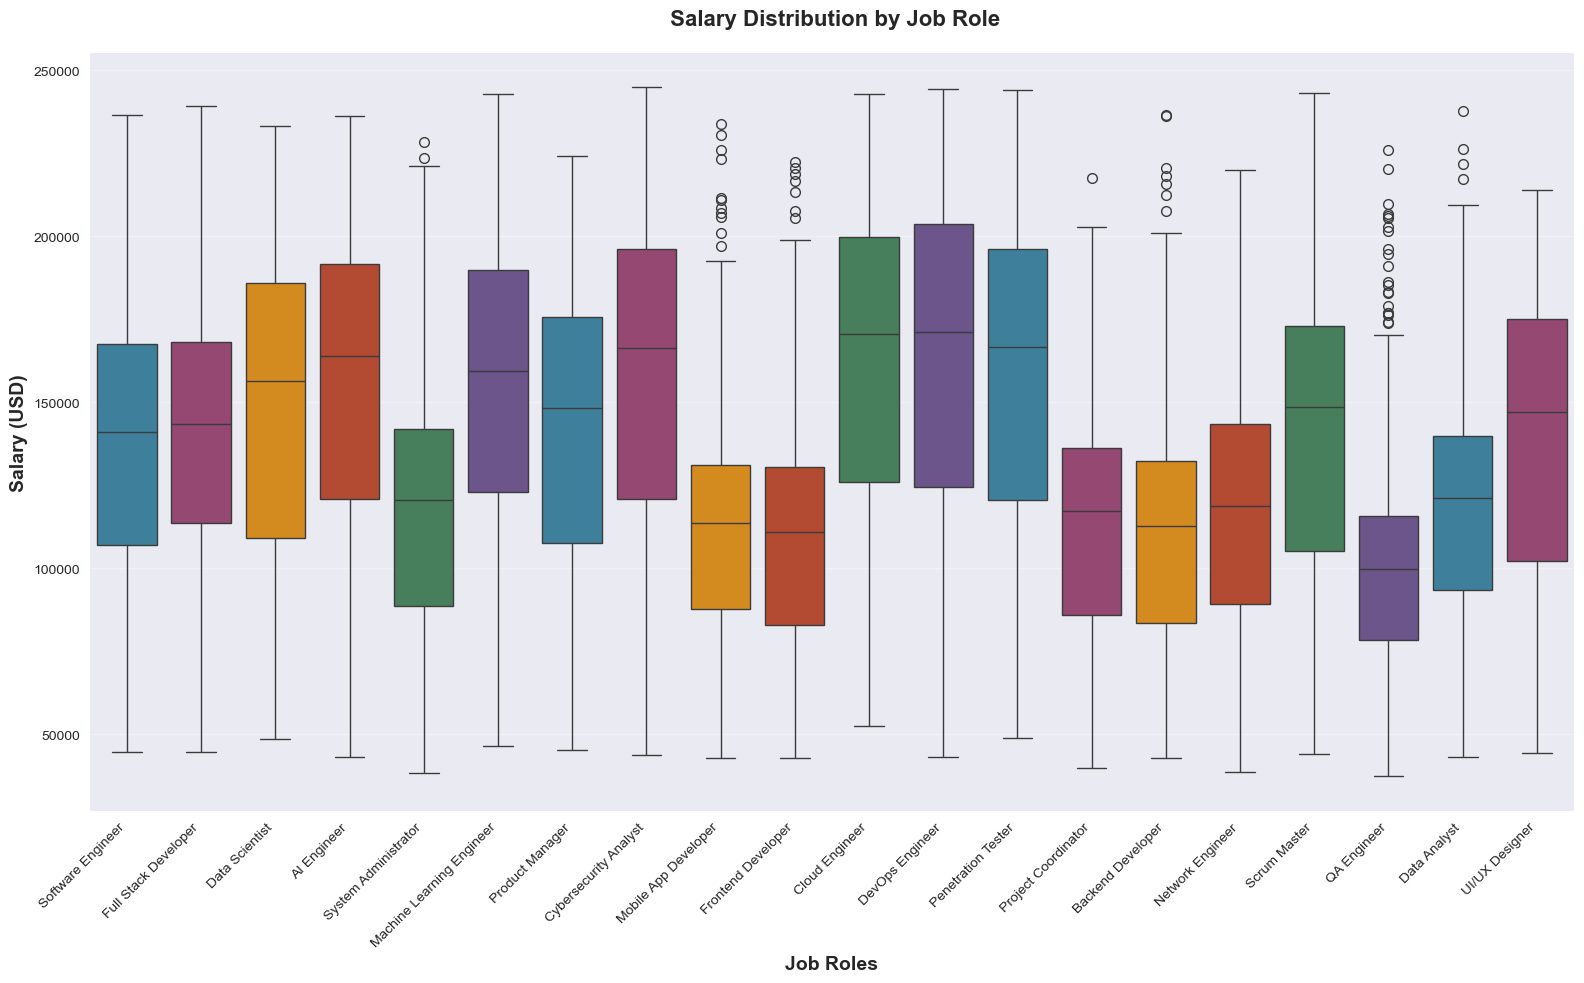

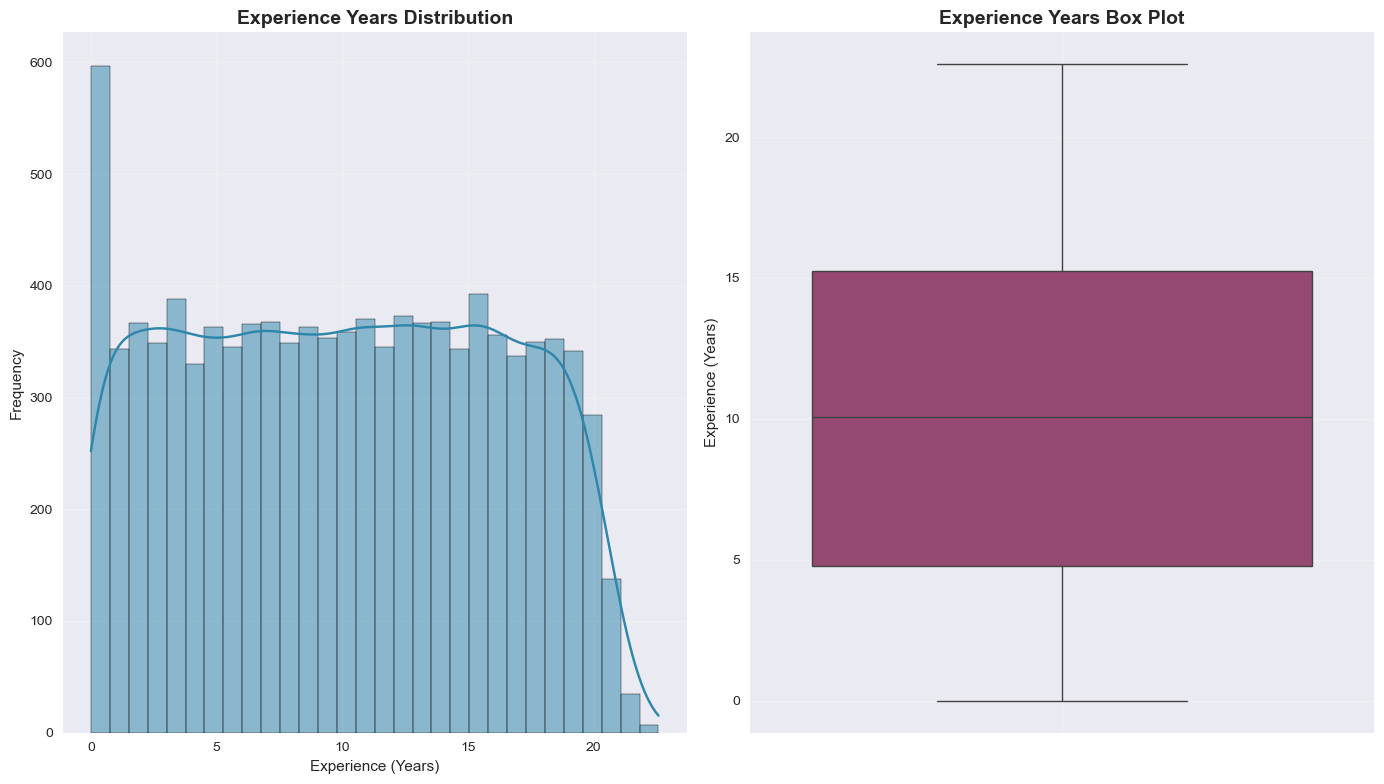


 Analyzing Top Skills...


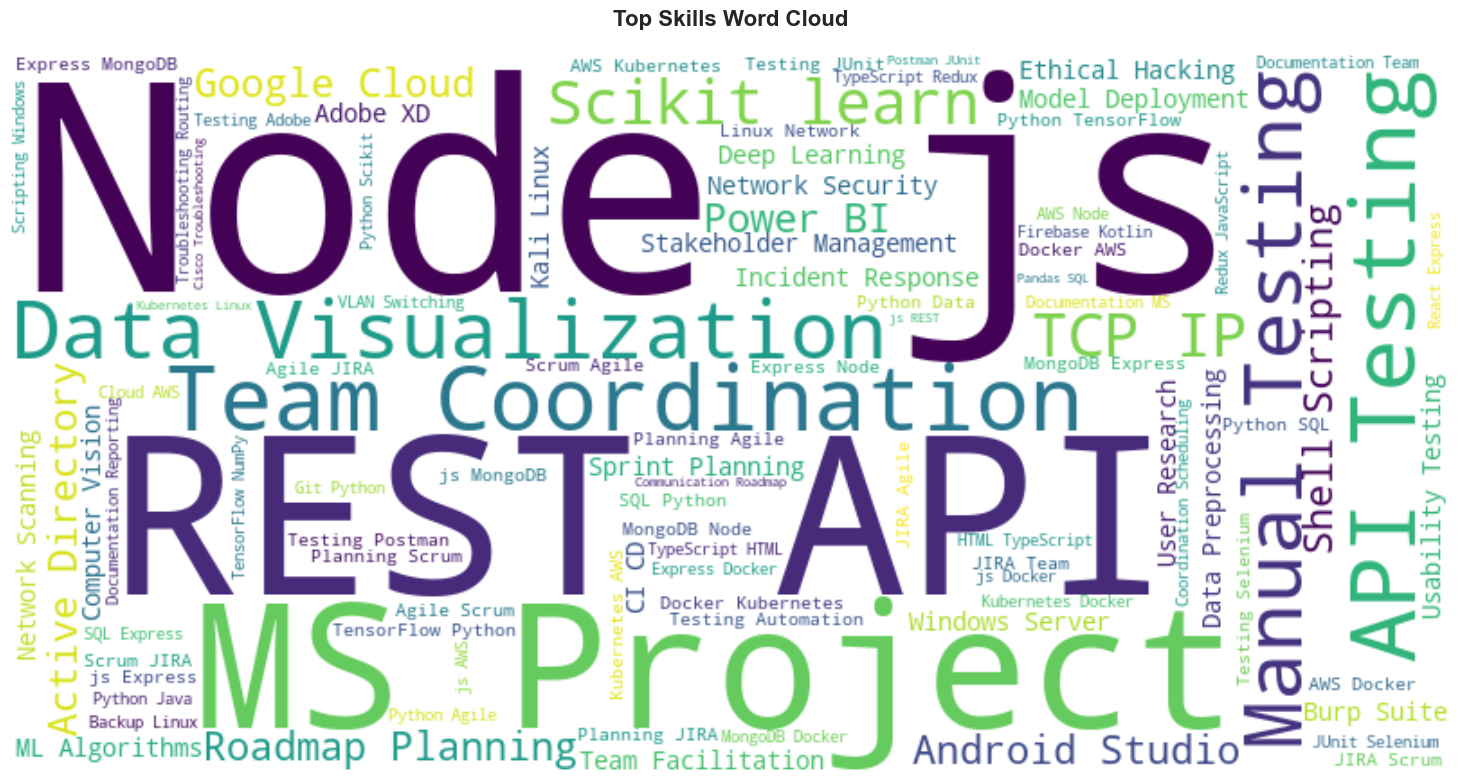

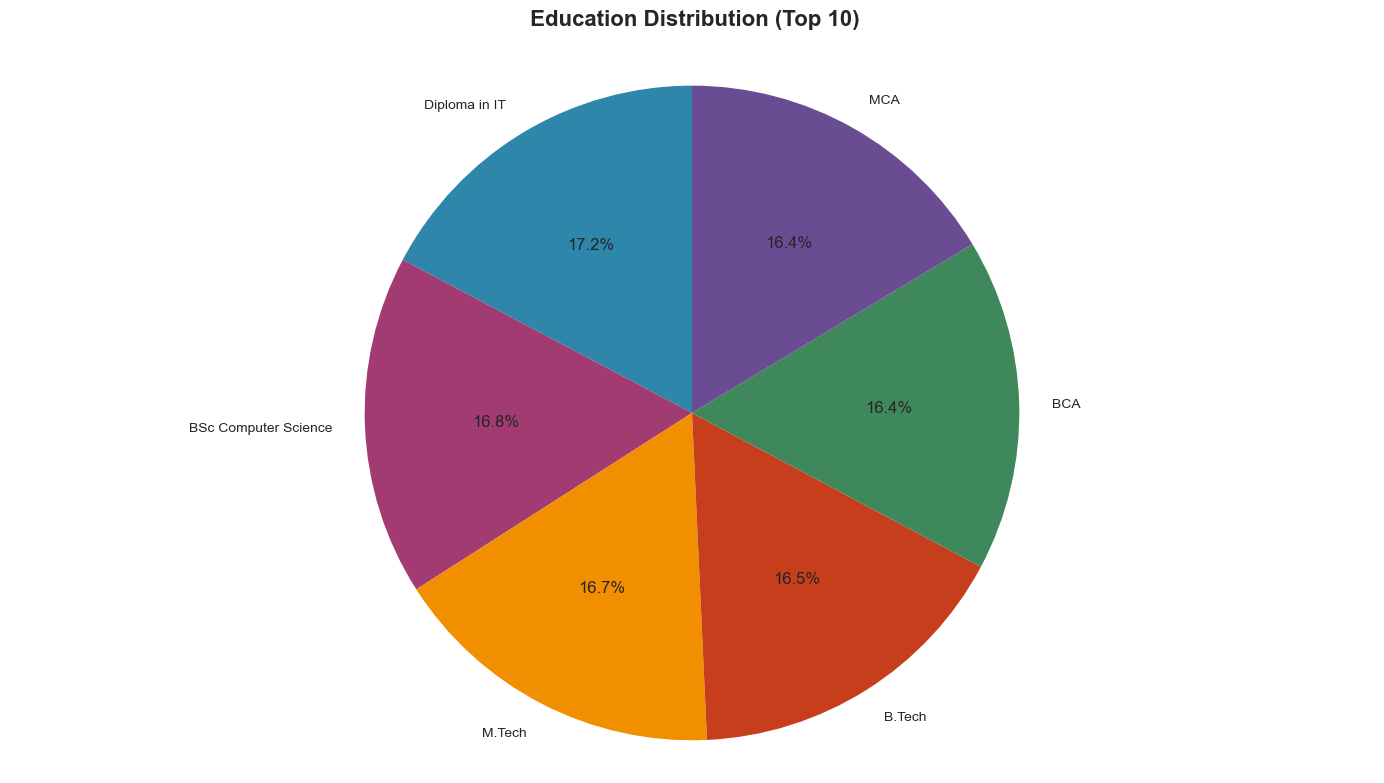

 Exploratory Data Analysis Complete!


In [5]:
# =============================================
# 2.5. EXPLORATORY DATA ANALYSIS VISUALIZATIONS
# =============================================
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Color palette
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3E885B', '#6A4C93']

print(" EXPLORATORY DATA ANALYSIS")
print("=" * 50)

# 1. Distribution of Job Roles
plt.figure(figsize=(16, 10))
job_counts = df['Applied_Job_Role'].value_counts()
bars = plt.bar(job_counts.index, job_counts.values, color=colors, edgecolor='black', alpha=0.8)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.title(' Distribution of Applied Job Roles', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Job Roles', fontsize=14, fontweight='bold')
plt.ylabel('Count', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Salary Distribution by Job Role
plt.figure(figsize=(16, 10))
sns.boxplot(data=df, x='Applied_Job_Role', y='Salary_USD', palette=colors)
plt.title(' Salary Distribution by Job Role', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Job Roles', fontsize=14, fontweight='bold')
plt.ylabel('Salary (USD)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Experience Years Distribution
plt.figure(figsize=(14, 8))
plt.subplot(1, 2, 1)
sns.histplot(df['Experience_Years'], bins=30, kde=True, color=colors[0])
plt.title('Experience Years Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Experience (Years)')
plt.ylabel('Frequency')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
sns.boxplot(y=df['Experience_Years'], color=colors[1])
plt.title('Experience Years Box Plot', fontsize=14, fontweight='bold')
plt.ylabel('Experience (Years)')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# 4. Top Skills Word Cloud
print("\n Analyzing Top Skills...")
all_skills = ' '.join(df['Skills'].dropna()).replace(',', ' ')
wordcloud = WordCloud(width=800, height=400, background_color='white', 
                      colormap='viridis', max_words=100).generate(all_skills)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Top Skills Word Cloud', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# 5. Education Distribution
plt.figure(figsize=(14, 8))
edu_counts = df['Education'].value_counts().head(10)
wedges, texts, autotexts = plt.pie(edu_counts.values, labels=edu_counts.index, 
                                   colors=colors, autopct='%1.1f%%', startangle=90)
plt.title(' Education Distribution (Top 10)', fontsize=16, fontweight='bold', pad=20)
plt.axis('equal')
plt.tight_layout()
plt.show()

print(" Exploratory Data Analysis Complete!")
print("=" * 50)

In [6]:
# =============================================
# 3. DEFINE FEATURES & TARGET
# =============================================
# Features for both models
X = df[["Skills", "Education", "Experience_Years"]]

# Target for Model 1 (Classification)
y_job = df["Applied_Job_Role"]

# Target for Model 2 (Regression)
y_salary = df["Salary_USD"]

# Train/Test split (same split for both models to keep consistency)
X_train, X_test, y_job_train, y_job_test, y_salary_train, y_salary_test = train_test_split(
    X, y_job, y_salary, test_size=0.20, random_state=42, stratify=y_job
)


In [7]:
# =============================================
# 4. PREPROCESSING (TF-IDF + SCALER)
# =============================================
skills_tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

edu_tfidf = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1,2)
)

preprocessor = ColumnTransformer(
    transformers=[
        ("skills_vec", skills_tfidf, "Skills"),
        ("edu_vec", edu_tfidf, "Education"),
        ("exp_scale", StandardScaler(), ["Experience_Years"])
    ]
)



In [8]:
job_clf = RandomForestClassifier(
    n_estimators=600,
    random_state=42,
    n_jobs=-1
)

job_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("classifier", job_clf)
])

print("Training Job Role Classifier...")
job_pipeline.fit(X_train, y_job_train)
print("Job Role Model Trained!")


Training Job Role Classifier...
Job Role Model Trained!


In [9]:
y_job_pred = job_pipeline.predict(X_test)

job_acc = accuracy_score(y_job_test, y_job_pred)
print("Job Prediction Accuracy:", job_acc)

print("\nClassification Report:\n")
print(classification_report(y_job_test, y_job_pred))


Job Prediction Accuracy: 0.895

Classification Report:

                           precision    recall  f1-score   support

              AI Engineer       0.87      0.91      0.89        95
        Backend Developer       0.88      0.91      0.90       103
           Cloud Engineer       0.92      0.89      0.91        97
    Cybersecurity Analyst       0.85      0.89      0.87        92
             Data Analyst       0.89      0.92      0.90       102
           Data Scientist       0.87      0.88      0.88       102
          DevOps Engineer       0.92      0.79      0.85        97
       Frontend Developer       0.88      0.87      0.88       106
     Full Stack Developer       0.88      0.89      0.89       101
Machine Learning Engineer       0.96      0.89      0.93        92
     Mobile App Developer       0.89      0.90      0.90       103
         Network Engineer       0.89      0.91      0.90       107
       Penetration Tester       0.90      0.90      0.90        96
     

In [10]:
job_model_path = "job_role_classifier.pkl"
joblib.dump(job_pipeline, job_model_path)

print("Job prediction model saved:", job_model_path)


Job prediction model saved: job_role_classifier.pkl


In [11]:
salary_reg = RandomForestRegressor(
    n_estimators=600,
    random_state=42,
    n_jobs=-1
)

salary_pipeline = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", salary_reg)
])

print("Training Salary Prediction Model...")
salary_pipeline.fit(X_train, y_salary_train)
print("Salary Model Trained!")



Training Salary Prediction Model...
Salary Model Trained!


In [12]:
salary_pred = salary_pipeline.predict(X_test)

mae = mean_absolute_error(y_salary_test, salary_pred)
mse = mean_squared_error(y_salary_test, salary_pred)
rmse = np.sqrt(mse)

print("Salary Prediction Evaluation:")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)


Salary Prediction Evaluation:
MAE : 12232.274434587147
MSE : 252265584.1230665
RMSE: 15882.870777131775


In [13]:
MODEL_PATH = "salary_prediction_model.pkl"

joblib.dump(salary_pipeline, MODEL_PATH)

print("Salary model saved as:", MODEL_PATH)


Salary model saved as: salary_prediction_model.pkl


In [14]:
def predict_job_and_salary(skills, education, experience):
    # Prepare a one-row input dataframe
    data = pd.DataFrame([{
        "Skills": skills,
        "Education": education,
        "Experience_Years": experience
    }])
    
    job_result = job_pipeline.predict(data)[0]
    salary_result = salary_pipeline.predict(data)[0]

    return job_result, round(salary_result, 2)

# Test example
predict_job_and_salary(
    "Python, Java, C#, CSS, HTML,PHP, Javascript",
    "BSC,Diploma",
    1
)


('Frontend Developer', np.float64(60562.8))

 FINAL MODEL DASHBOARD


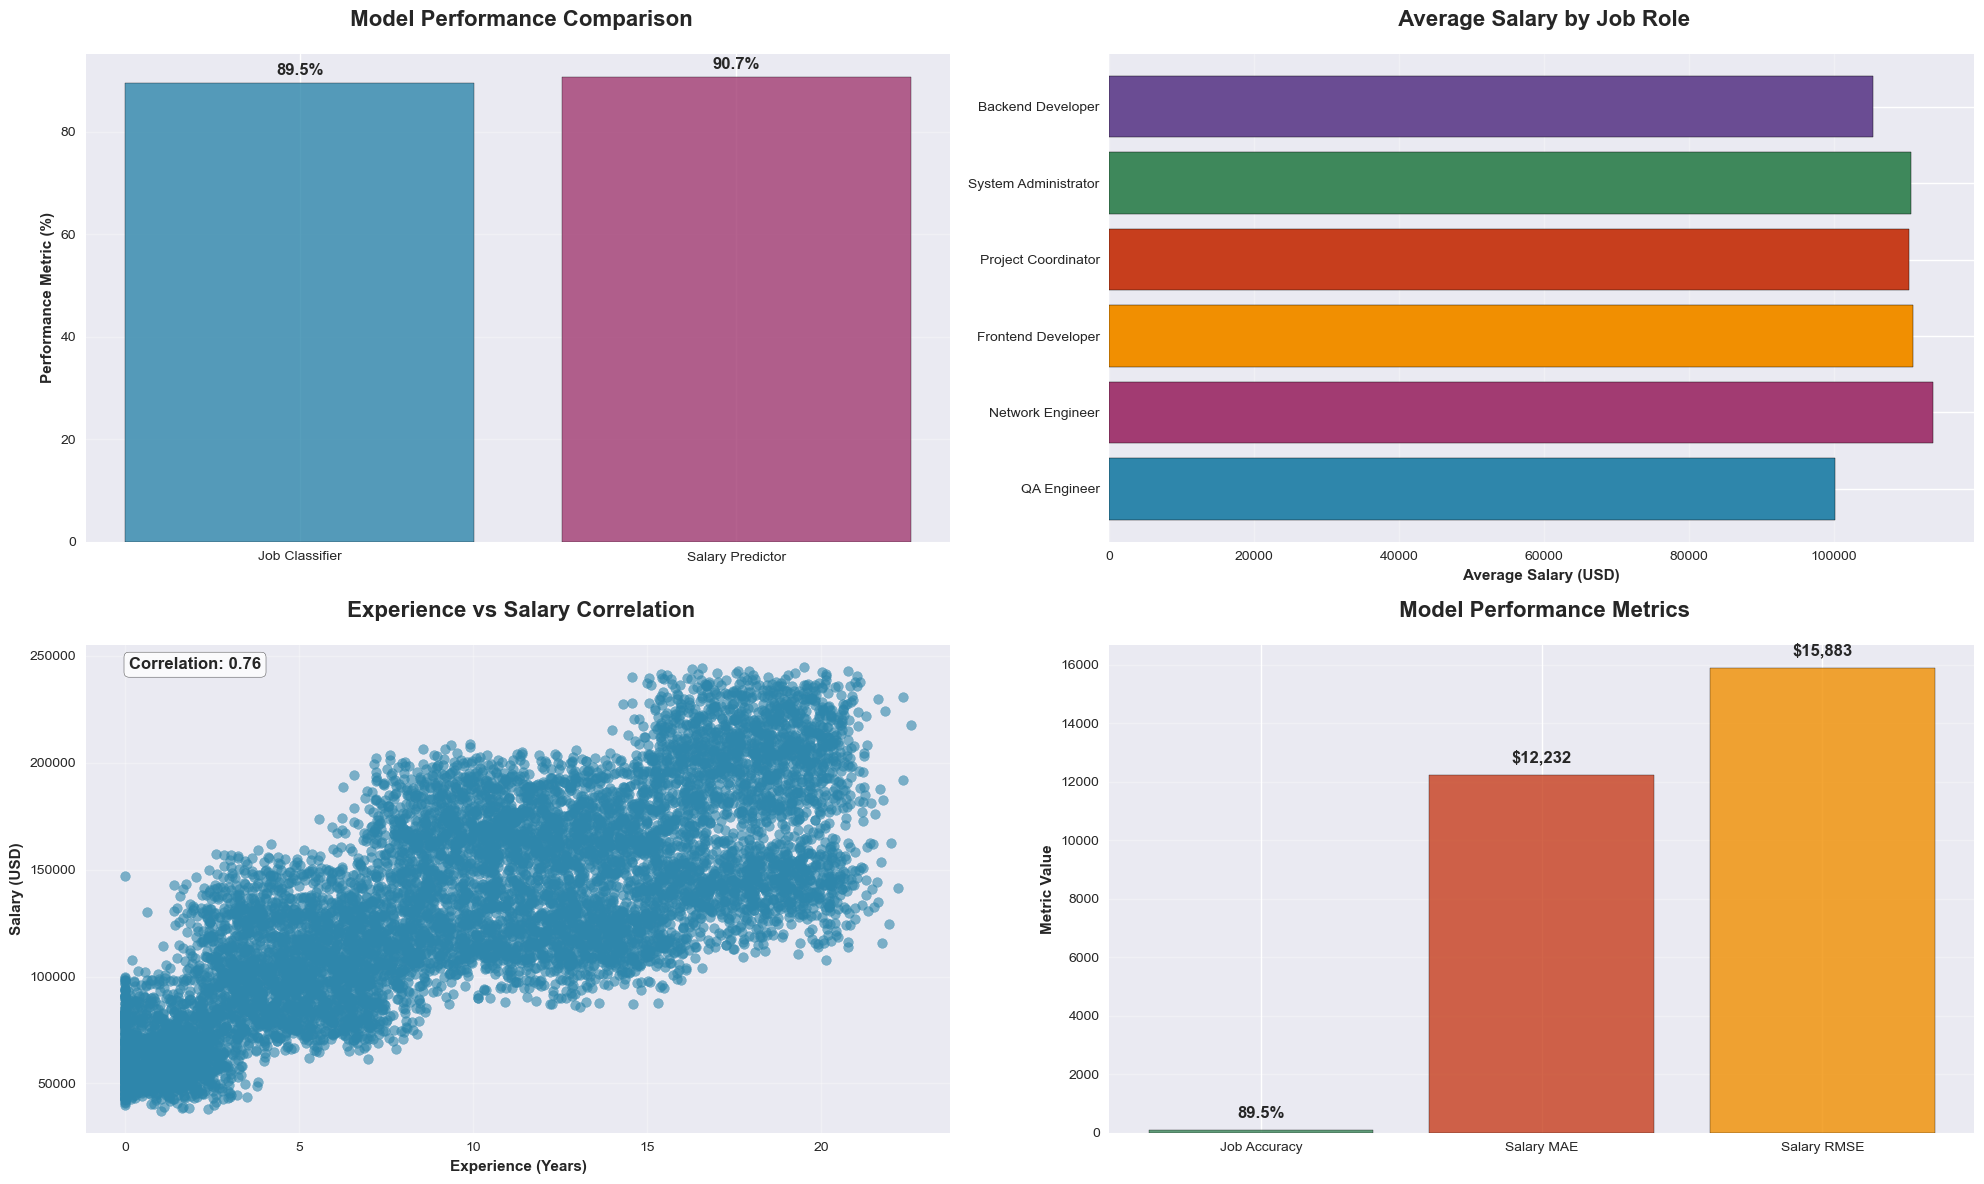

In [15]:
# =============================================
# 12. COMPREHENSIVE RESULTS DASHBOARD
# =============================================
print(" FINAL MODEL DASHBOARD")
print("=" * 50)

# Create a comprehensive summary visualization
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 12))

# 1. Model Accuracy Comparison
models = ['Job Classifier', 'Salary Predictor']
accuracies = [job_acc * 100, (1 - (mae / y_salary_test.mean())) * 100]
colors_acc = ['#2E86AB', '#A23B72']

bars1 = ax1.bar(models, accuracies, color=colors_acc, edgecolor='black', alpha=0.8)
ax1.set_title(' Model Performance Comparison', fontsize=16, fontweight='bold', pad=20)
ax1.set_ylabel('Performance Metric (%)', fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

# 2. Salary Prediction Range by Job Role
job_salary_pred = X_test.copy()
job_salary_pred['Actual_Job'] = y_job_test
job_salary_pred['Predicted_Job'] = y_job_pred
job_salary_pred['Actual_Salary'] = y_salary_test
job_salary_pred['Predicted_Salary'] = salary_pred

top_jobs = job_salary_pred['Actual_Job'].value_counts().index[:6]
job_salary_means = job_salary_pred.groupby('Actual_Job')['Actual_Salary'].mean().loc[top_jobs]

ax2.barh(range(len(top_jobs)), job_salary_means.values, color=colors, edgecolor='black')
ax2.set_yticks(range(len(top_jobs)))
ax2.set_yticklabels(top_jobs)
ax2.set_xlabel('Average Salary (USD)', fontweight='bold')
ax2.set_title(' Average Salary by Job Role', fontsize=16, fontweight='bold', pad=20)
ax2.grid(axis='x', alpha=0.3)

# 3. Experience vs Salary
ax3.scatter(df['Experience_Years'], df['Salary_USD'], alpha=0.6, color=colors[0])
ax3.set_xlabel('Experience (Years)', fontweight='bold')
ax3.set_ylabel('Salary (USD)', fontweight='bold')
ax3.set_title(' Experience vs Salary Correlation', fontsize=16, fontweight='bold', pad=20)
ax3.grid(alpha=0.3)

# Add correlation coefficient
correlation = df['Experience_Years'].corr(df['Salary_USD'])
ax3.text(0.05, 0.95, f'Correlation: {correlation:.2f}', 
         transform=ax3.transAxes, fontsize=12, fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# 4. Model Success Summary
success_metrics = ['Job Accuracy', 'Salary MAE', 'Salary RMSE']
success_values = [job_acc * 100, mae, rmse]
success_colors = ['#3E885B', '#C73E1D', '#F18F01']

bars4 = ax4.bar(success_metrics, success_values, color=success_colors, edgecolor='black', alpha=0.8)
ax4.set_title(' Model Performance Metrics', fontsize=16, fontweight='bold', pad=20)
ax4.set_ylabel('Metric Value', fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# Add value labels
for bar, metric in zip(bars4, success_metrics):
    height = bar.get_height()
    if metric == 'Job Accuracy':
        label = f'{height:.1f}%'
    else:
        label = f'${height:,.0f}'
    ax4.text(bar.get_x() + bar.get_width()/2., height + (0.02 * max(success_values)),
             label, ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()




In [16]:
# =============================================
# SHOW ALL UNIQUE SKILLS
# =============================================

# Step 1: Take the Skills column and drop missing values
skills_series = df['Skills'].dropna()

# Step 2: Split skills by comma and flatten them into one list
all_skills = skills_series.str.split(',').explode()

# Step 3: Clean spaces (important for correctness)
all_skills = all_skills.str.strip()

# Step 4: Get unique skills and sort them
unique_skills = sorted(all_skills.unique())

# Step 5: Display results
print("Total number of unique skills:", len(unique_skills))
print("\nList of all skills:\n")

for skill in unique_skills:
    print(skill)


Total number of unique skills: 94

List of all skills:

API Testing
AWS
Active Directory
Adobe XD
Agile
Android Studio
Automation
Azure
Backup
Burp Suite
C++
CI/CD
CSS
Cisco
Communication
Computer Vision
Dart
Data Preprocessing
Data Visualization
Deep Learning
Docker
Documentation
Ethical Hacking
Excel
Express
Figma
Firebase
Firewalls
Flutter
Git
Google Cloud
HTML
Incident Response
JIRA
JUnit
Java
JavaScript
Jenkins
Kali Linux
Keras
Kotlin
Kubernetes
Linux
ML Algorithms
MLOps
MS Project
Manual Testing
Metasploit
Model Deployment
MongoDB
NLP
Network Scanning
Network Security
Node.js
NumPy
OOP
Pandas
Postman
Power BI
Prototyping
PyTorch
Python
REST API
React
Redux
Reporting
Retrospective
Roadmap Planning
Routing
SIEM
SQL
Scheduling
Scikit-learn
Scrum
Selenium
Shell Scripting
Sprint Planning
Stakeholder Management
Switching
TCP/IP
Tableau
Team Coordination
Team Facilitation
TensorFlow
Terraform
Troubleshooting
TypeScript
Usability Testing
User Research
VLAN
VMware
Windows Server
Wireframi

In [17]:
# =============================================
# SHOW ALL UNIQUE EDUCATION VALUES
# =============================================

unique_education = sorted(df['Education'].dropna().unique())

print("Total number of education levels:", len(unique_education))
print("\nList of all education values:\n")

for edu in unique_education:
    print(edu)


Total number of education levels: 6

List of all education values:

B.Tech
BCA
BSc Computer Science
Diploma in IT
M.Tech
MCA


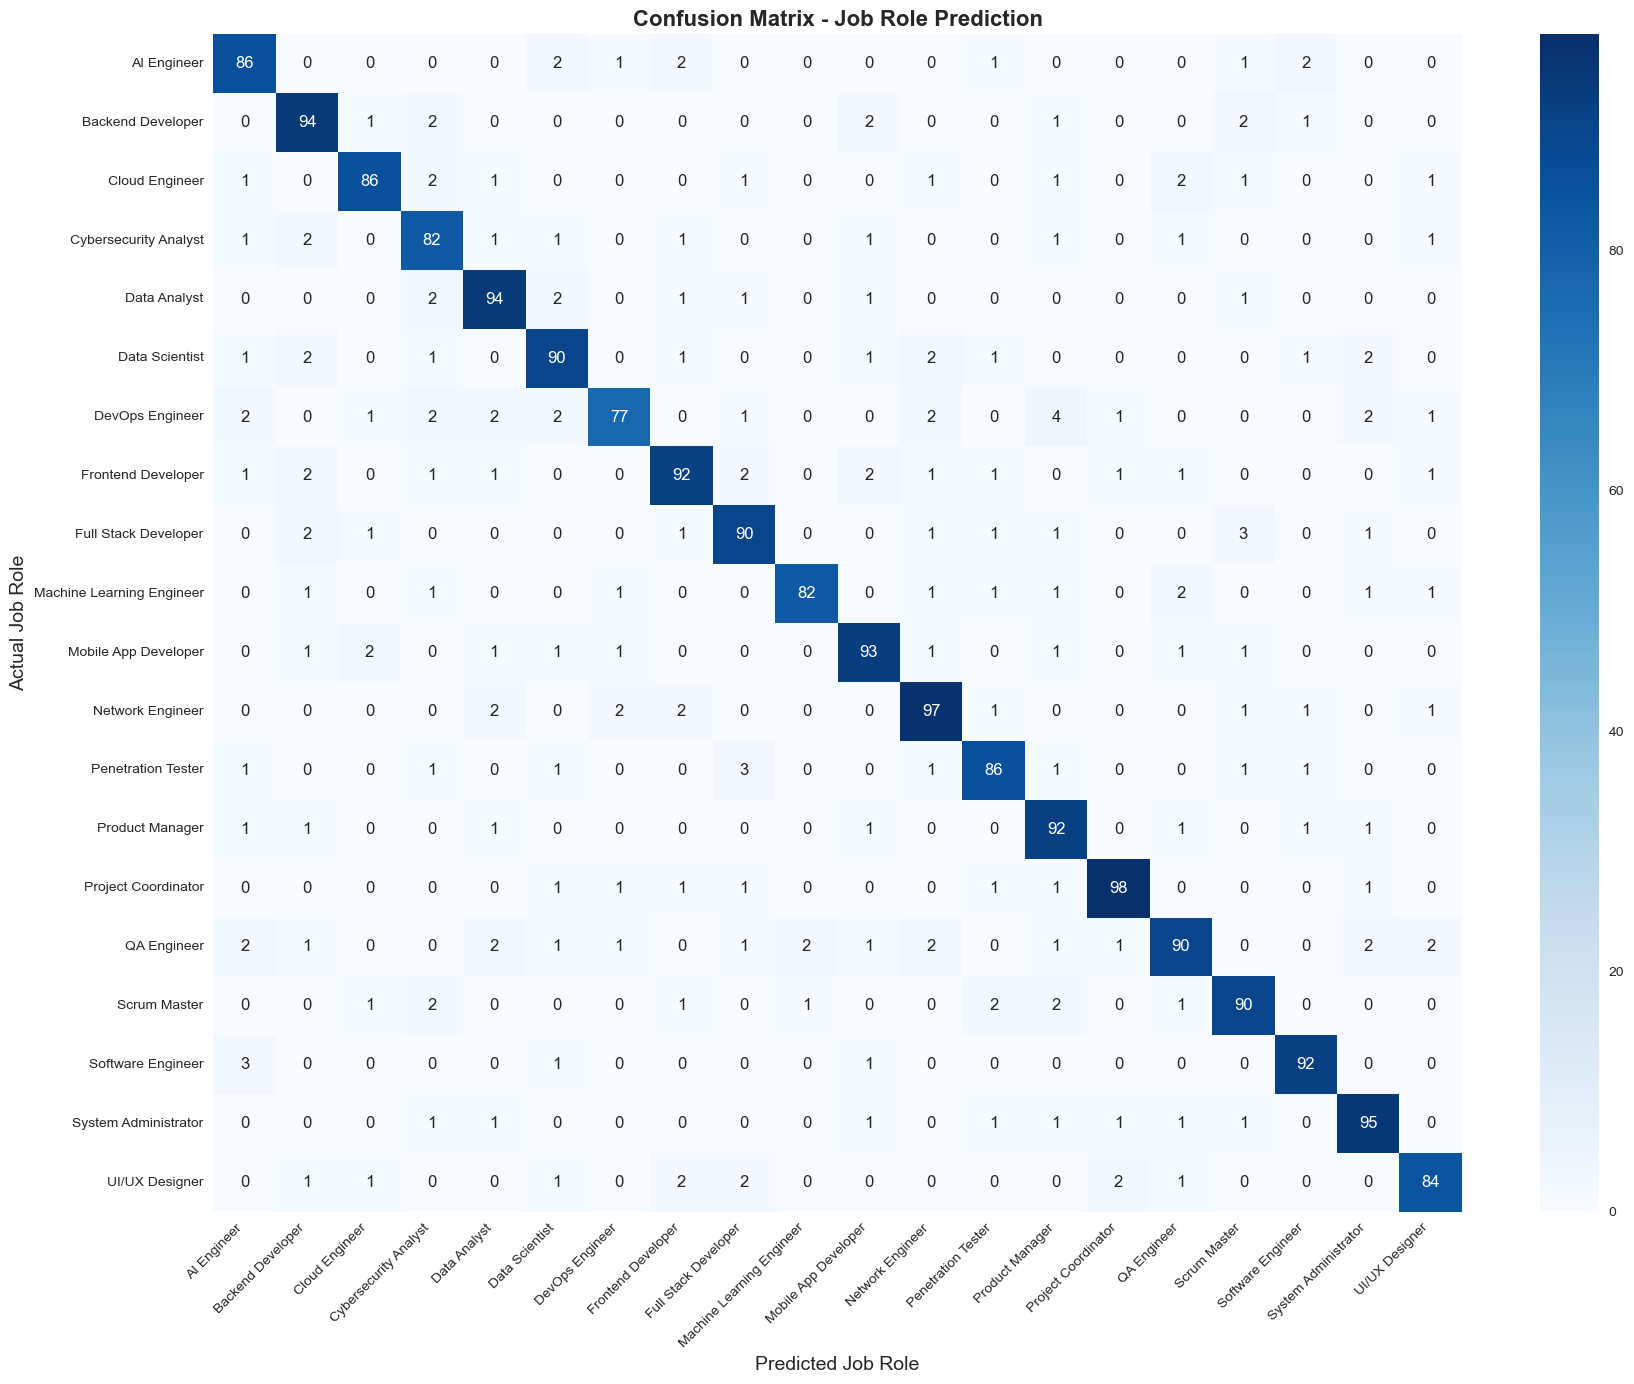

In [18]:
# =============================================
# CONFUSION MATRIX (JOB ROLE CLASSIFICATION)
# =============================================
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_job_test, y_job_pred)


plt.figure(figsize=(18, 14))

sns.heatmap(
    cm,
    annot=True,           # show numbers
    fmt='d',              # integer values
    cmap='Blues',         # color style
    xticklabels=job_pipeline.classes_,
    yticklabels=job_pipeline.classes_
)

plt.title("Confusion Matrix - Job Role Prediction", fontsize=16, fontweight='bold')
plt.xlabel("Predicted Job Role", fontsize=14)
plt.ylabel("Actual Job Role", fontsize=14)

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


In [19]:
def predict_job_salary_with_confidence(skills, education, experience):
    # Step 1: Prepare input data
    data = pd.DataFrame([{
        "Skills": skills,
        "Education": education,
        "Experience_Years": experience
    }])

    # Step 2: Predict job
    job_prediction = job_pipeline.predict(data)[0]

    # Step 3: Get prediction probabilities
    job_probabilities = job_pipeline.predict_proba(data)[0]

    # Step 4: Get confidence of predicted job
    job_confidence = max(job_probabilities) * 100

    # Step 5: Predict salary
    salary_prediction = salary_pipeline.predict(data)[0]

    return {
        "Predicted Job Role": job_prediction,
        "Job Prediction Confidence (%)": round(job_confidence, 2),
        "Predicted Salary (USD)": round(float(salary_prediction), 2)
    }


In [20]:
result = predict_job_salary_with_confidence(
    "Python, Java, C#, CSS, HTML, JavaScript",
    "BSc Computer Science",
    1
)

result


{'Predicted Job Role': 'Frontend Developer',
 'Job Prediction Confidence (%)': np.float64(52.17),
 'Predicted Salary (USD)': 58346.25}

In [21]:
print("Overall Job Model Accuracy:", round(job_acc * 100, 2), "%")
print("Salary Model MAE:", round(mae, 2), "USD")


Overall Job Model Accuracy: 89.5 %
Salary Model MAE: 12232.27 USD


In [22]:
def predict_top3_jobs_and_salary(skills, education, experience):
    # =============================================
    # STEP 1: Prepare input data
    # =============================================
    data = pd.DataFrame([{
        "Skills": skills,
        "Education": education,
        "Experience_Years": experience
    }])

    # =============================================
    # STEP 2: Get probabilities for all job roles
    # =============================================
    job_probabilities = job_pipeline.predict_proba(data)[0]
    job_classes = job_pipeline.classes_

    # =============================================
    # STEP 3: Combine jobs with probabilities
    # =============================================
    job_prob_pairs = list(zip(job_classes, job_probabilities))

    # =============================================
    # STEP 4: Sort by probability (descending)
    # =============================================
    job_prob_pairs = sorted(
        job_prob_pairs,
        key=lambda x: x[1],
        reverse=True
    )

    # =============================================
    # STEP 5: Select top 3 jobs
    # =============================================
    top_3_jobs = job_prob_pairs[:3]

    # =============================================
    # STEP 6: Predict salary
    # =============================================
    salary_prediction = salary_pipeline.predict(data)[0]

    # =============================================
    # STEP 7: Format output
    # =============================================
    results = {
        "Top 3 Job Predictions": [
            {
                "Job Role": job,
                "Confidence (%)": round(prob * 100, 2)
            }
            for job, prob in top_3_jobs
        ],
        "Predicted Salary (USD)": round(float(salary_prediction), 2)
    }

    return results


In [23]:
prediction = predict_top3_jobs_and_salary(
    "Python, Java, C#, CSS, HTML, JavaScript",
    "BSc Computer Science",
    1
)

prediction


{'Top 3 Job Predictions': [{'Job Role': 'Frontend Developer',
   'Confidence (%)': np.float64(52.17)},
  {'Job Role': 'Software Engineer', 'Confidence (%)': np.float64(25.33)},
  {'Job Role': 'UI/UX Designer', 'Confidence (%)': np.float64(4.33)}],
 'Predicted Salary (USD)': 58346.25}

In [33]:
def predict_job_with_confidence(skills, education, experience):
    # Prepare input
    data = pd.DataFrame([{
        "Skills": skills,
        "Education": education,
        "Experience_Years": experience
    }])

    # Predict job
    predicted_job = job_pipeline.predict(data)[0]

    # Get probabilities
    probabilities = job_pipeline.predict_proba(data)[0]
    classes = job_pipeline.classes_

    # Get confidence of predicted job
    job_index = list(classes).index(predicted_job)
    confidence = probabilities[job_index] * 100

    return {
        "Predicted Job": predicted_job,
        "Prediction Confidence (%)": round(confidence, 2)
    }


In [47]:
def predict_job_and_salary(skills, education, experience):
    # Prepare a one-row input dataframe
    data = pd.DataFrame([{
        "Skills": skills,
        "Education": education,
        "Experience_Years": experience
    }])
    
    job_result = job_pipeline.predict(data)[0]
    salary_result = salary_pipeline.predict(data)[0]

    return job_result, round(salary_result, 2)


predict_job_and_salary(
    "angular,css,django,git,html,java,javascript,linux,mysql,python,sql",
    "BSc ",
    24
)




('Frontend Developer', np.float64(192942.26))